# 12 — Intraday event study (minuutdata)

**Doel**: Nu we minuut-level data hebben, kunnen we meten of de markt reageert
**binnen minuten** na een Trump-post — niet pas de volgende dag.

**Onderzoeksvragen:**
1. Is er een abnormale return in de eerste 5/15/30/60 minuten na een post?
2. Verdwijnt het effect snel (mean reversion) of houdt het aan?
3. Verschilt de snelheid van reactie tussen tariff-posts en Iran-posts?
4. Zijn er volume-anomalieën direct na de post (handelsdrukte als proxy voor aandacht)?

**Data:**
- `data/processed/intraday_spy_tariff_1min.parquet` — SPY minuutdata rond tariff-posts
- `data/processed/intraday_xle_tariff_1min.parquet` — XLE (WTI-proxy) rond tariff-posts
- `data/processed/intraday_spy_iran_1min.parquet` — SPY rond Iran-posts
- `data/processed/intraday_xle_iran_1min.parquet` — XLE rond Iran-posts

**Methode**: Cumulative Abnormal Return (CAR) — standaard in academische event studies.
Baseline = gemiddelde return in de 30 minuten *vóór* de post (estimation window).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')

DATA = Path('../data')
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# Event windows (minuten na post)
WINDOWS = [5, 15, 30, 60, 120]
# Estimation window: minuten vóór post voor baseline
ESTIMATION_MIN = 30

print('Setup klaar.')

Setup klaar.


## 1. Laad data

In [2]:
def load_intraday(ticker: str, topic: str) -> pd.DataFrame:
    p = DATA / f'processed/intraday_{ticker.lower()}_{topic}_1min.parquet'
    try:
        df = pd.read_parquet(p, engine='pyarrow')
    except Exception:
        df = pd.read_parquet(p, engine='fastparquet')
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
    df = df.sort_values('datetime').reset_index(drop=True)
    df['return'] = np.log(df['close'] / df['close'].shift(1))
    return df

spy_tariff = load_intraday('spy', 'tariff')
xle_tariff = load_intraday('xle', 'tariff')
spy_iran   = load_intraday('spy', 'iran')
xle_iran   = load_intraday('xle', 'iran')

for name, df in [('SPY/tariff', spy_tariff), ('XLE/tariff', xle_tariff),
                 ('SPY/iran',   spy_iran),   ('XLE/iran',   xle_iran)]:
    print(f'{name}: {len(df):,} minuten | {df["datetime"].min().date()} → {df["datetime"].max().date()}')

SPY/tariff: 14,726 minuten | 2025-02-03 → 2025-06-27
XLE/tariff: 14,400 minuten | 2025-02-03 → 2025-06-27
SPY/iran: 7,964 minuten | 2026-03-02 → 2026-06-01
XLE/iran: 7,964 minuten | 2026-03-02 → 2026-06-01


## 2. Laad posts en koppel aan minuutdata

In [3]:
def load_posts(parquet_path: str, keywords: list) -> pd.Series:
    # pyarrow eerst (consistente string-kolommen); fastparquet als fallback.
    try:
        df = pd.read_parquet(parquet_path, engine='pyarrow')
    except Exception:
        df = pd.read_parquet(parquet_path, engine='fastparquet')
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
    # Forceer string-dtype: sommige parquet-exports leveren 'text' als bytes/anders
    # in, waardoor .str.contains overal False geeft (en de filtering 0 oplevert).
    text = df['text'].astype('string').fillna('')
    pattern = '|'.join(keywords)
    mask = text.str.lower().str.contains(pattern, na=False, regex=True)
    return df[mask]['timestamp_utc'].sort_values().reset_index(drop=True)

TARIFF_KW = ['tariff','tariffs','reciprocal','liberation day','trade war','trade deal',
    'trade deficit','china','chinese','beijing','xi jinping','europe','european union',
    'canada','mexico','retaliat','deal','negotiat','pause','truce','exemption','sanction']

IRAN_KW = ['iran','iranian','tehran','ayatollah','irgc','hormuz','persian gulf',
    'israel','houthi','opec','saudi','oil','crude','barrel','missile','nuclear','sanctions']

tariff_ts = load_posts('../data/raw/posts.parquet', TARIFF_KW)
tariff_ts = tariff_ts[
    (tariff_ts >= pd.Timestamp('2025-02-01', tz='UTC')) &
    (tariff_ts <= pd.Timestamp('2025-07-01', tz='UTC'))
]

iran_ts = load_posts('../data/raw/posts_live.parquet', IRAN_KW)
iran_ts = iran_ts[iran_ts >= pd.Timestamp('2026-02-28', tz='UTC')]

print(f'Tariff posts in venster: {len(tariff_ts)}')
print(f'Iran posts in venster:   {len(iran_ts)}')

Tariff posts in venster: 298
Iran posts in venster:   266


## 3. Compute Cumulative Abnormal Returns (CAR)

Voor elke post:
- **Baseline** = gemiddelde minuut-return in de 30 minuten vóór de post (estimation window)
- **AR(t)** = werkelijke return op minuut t − baseline
- **CAR(0→T)** = cumulatieve som van AR over het event window

Alleen posts tijdens markturen worden meegenomen (09:30–16:00 ET = 13:30–20:00 UTC).

In [4]:
def is_market_hours(ts: pd.Timestamp) -> bool:
    """True als post valt binnen NYSE markturen (incl. pre/post-market buffer)."""
    # NYSE: 09:30–16:00 ET = 13:30–20:00 UTC (winter) / 13:30–20:00 UTC
    # Ruime definitie: 13:00–21:00 UTC om pre/post-market te vangen
    return 13 <= ts.hour < 21 and ts.weekday() < 5

def compute_car(post_time: pd.Timestamp, market_df: pd.DataFrame,
                windows: list = WINDOWS,
                estimation_min: int = ESTIMATION_MIN) -> dict:
    """
    Bereken CAR voor één post op basis van minuutdata.
    Returns dict met CAR per window + baseline info.
    """
    result = {'post_time': post_time, 'in_market_hours': is_market_hours(post_time)}

    # Estimation window: [post_time - estimation_min, post_time]
    est_start = post_time - pd.Timedelta(minutes=estimation_min)
    est_data  = market_df[
        (market_df['datetime'] > est_start) &
        (market_df['datetime'] <= post_time)
    ]['return'].dropna()

    if len(est_data) < 5:
        # Niet genoeg data voor baseline
        for w in windows:
            result[f'car_{w}m'] = np.nan
        result['baseline_mean'] = np.nan
        result['n_estimation'] = len(est_data)
        return result

    baseline = est_data.mean()
    result['baseline_mean'] = baseline
    result['n_estimation']  = len(est_data)

    # Event window returns
    for w in windows:
        event_data = market_df[
            (market_df['datetime'] > post_time) &
            (market_df['datetime'] <= post_time + pd.Timedelta(minutes=w))
        ]['return'].dropna()

        if event_data.empty:
            result[f'car_{w}m'] = np.nan
        else:
            # CAR = som van (return - baseline) over event window
            ar = event_data - baseline
            result[f'car_{w}m'] = float(ar.sum())

    return result

print('compute_car() gedefinieerd.')

compute_car() gedefinieerd.


In [5]:
# Bereken CAR voor alle tariff- en Iran-posts op SPY en XLE
_CAR_COLS = ['post_time', 'in_market_hours', 'baseline_mean', 'n_estimation'] + [f'car_{w}m' for w in WINDOWS]

def build_cars(post_times, market_df):
    rows = [compute_car(t, market_df) for t in post_times]
    df = pd.DataFrame(rows)
    # Garandeer schema, ook bij lege postenlijst -> voorkomt KeyError downstream
    return df.reindex(columns=_CAR_COLS)

print('Berekenen CAR tariff posts...')
tariff_spy_cars = build_cars(tariff_ts, spy_tariff)
tariff_xle_cars = build_cars(tariff_ts, xle_tariff)

print('Berekenen CAR Iran posts...')
iran_spy_cars   = build_cars(iran_ts, spy_iran)
iran_xle_cars   = build_cars(iran_ts, xle_iran)

for name, df in [('tariff/SPY', tariff_spy_cars), ('tariff/XLE', tariff_xle_cars),
                 ('iran/SPY',   iran_spy_cars),   ('iran/XLE',   iran_xle_cars)]:
    total  = len(df)
    market = int(df['in_market_hours'].sum()) if total else 0
    valid  = int(df['car_30m'].notna().sum()) if total else 0
    flag = '' if total else '  <-- LEEG: draai cel 5 opnieuw (tariff_ts/iran_ts) of Restart & Run All'
    print(f'{name}: {total} posts | {market} tijdens markturen | {valid} met geldige CAR{flag}')


Berekenen CAR tariff posts...
Berekenen CAR Iran posts...
tariff/SPY: 298 posts | 132 tijdens markturen | 97 met geldige CAR
tariff/XLE: 298 posts | 132 tijdens markturen | 96 met geldige CAR
iran/SPY: 266 posts | 84 tijdens markturen | 54 met geldige CAR
iran/XLE: 266 posts | 84 tijdens markturen | 54 met geldige CAR


## 4. CAR-profiel: gemiddelde CAR over tijd

Plot de gemiddelde CAR per minuut-window — dit toont *hoe snel* de markt reageert.

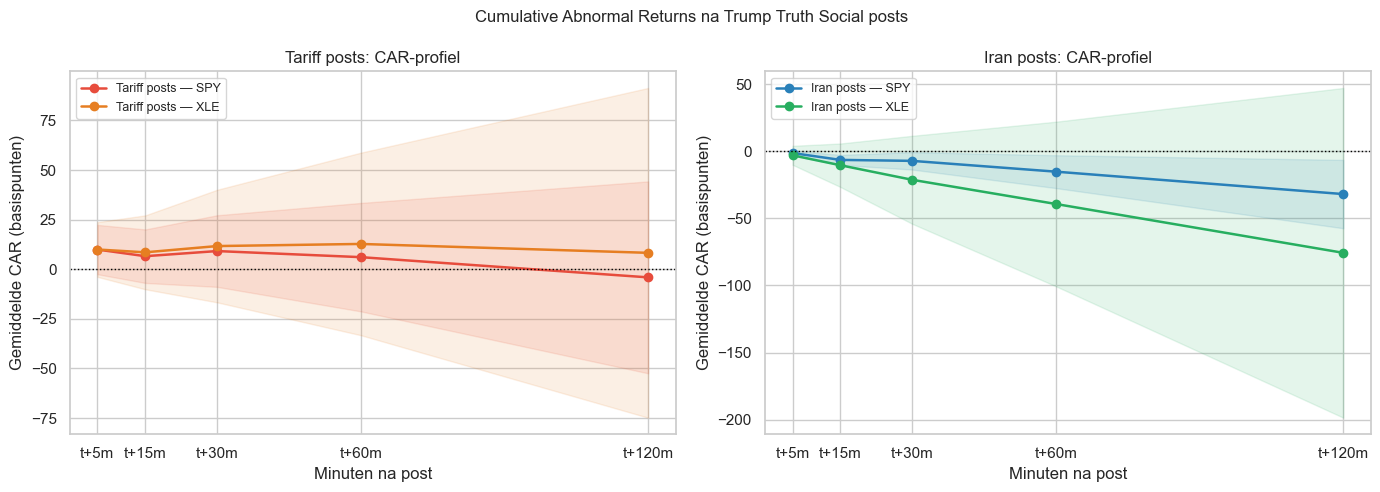

Opgeslagen: reports/figures/12_intraday_car_profile.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

car_cols = [f'car_{w}m' for w in WINDOWS]
labels   = [f't+{w}m' for w in WINDOWS]

plot_data = [
    ('Tariff posts — SPY', tariff_spy_cars, '#e74c3c', axes[0]),
    ('Tariff posts — XLE', tariff_xle_cars, '#e67e22', axes[0]),
    ('Iran posts — SPY',   iran_spy_cars,   '#2980b9', axes[1]),
    ('Iran posts — XLE',   iran_xle_cars,   '#27ae60', axes[1]),
]

for label, df, color, ax in plot_data:
    # Filter op markturen en geldige CAR
    sub = df[df['in_market_hours'] & df['car_5m'].notna()]
    means = [sub[c].mean() * 1e4 for c in car_cols]  # in basispunten
    sems  = [sub[c].sem()  * 1e4 for c in car_cols]
    ax.plot(WINDOWS, means, marker='o', label=label, color=color, linewidth=1.8)
    ax.fill_between(WINDOWS,
                    [m - 1.96*s for m, s in zip(means, sems)],
                    [m + 1.96*s for m, s in zip(means, sems)],
                    alpha=0.12, color=color)

for ax in axes:
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('Minuten na post')
    ax.set_ylabel('Gemiddelde CAR (basispunten)')
    ax.set_xticks(WINDOWS)
    ax.set_xticklabels(labels)
    ax.legend(fontsize=9)

axes[0].set_title('Tariff posts: CAR-profiel')
axes[1].set_title('Iran posts: CAR-profiel')

plt.suptitle('Cumulative Abnormal Returns na Trump Truth Social posts', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '12_intraday_car_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: reports/figures/12_intraday_car_profile.png')

## 5. Statistieken: is de CAR significant van nul verschilend?

One-sample t-test: H0 = gemiddelde CAR = 0.

In [7]:
# One-sample bootstrap-CI op CAR (vervangt ttest_1samp tegen 0)
from src.evaluation.bootstrap import bootstrap_ci

rows = []
datasets = [
    ('tariff', 'SPY', tariff_spy_cars),
    ('tariff', 'XLE', tariff_xle_cars),
    ('iran',   'SPY', iran_spy_cars),
    ('iran',   'XLE', iran_xle_cars),
]

for topic, ticker, df in datasets:
    sub = df[df['in_market_hours']]
    for w in WINDOWS:
        col  = f'car_{w}m'
        vals = sub[col].dropna()
        if len(vals) < 5:
            continue
        b = bootstrap_ci(vals, stat=np.mean, h0=0.0)
        rows.append({
            'topic': topic, 'ticker': ticker,
            'window': f't+{w}m', 'n': len(vals),
            'mean_bp':   round(b['obs'] * 1e4, 2),
            'ci_low_bp': round(b['ci_low'] * 1e4, 2),
            'ci_high_bp':round(b['ci_high'] * 1e4, 2),
            'excludes_0': b['excludes_h0'],
        })

results = pd.DataFrame(rows)
print("CAR per topic x ticker x window met 95%-bootstrap-CI (excludes_0=True ~ significant verschillend van nul):")
print(results.to_string(index=False))


CAR per topic x ticker x window met 95%-bootstrap-CI (excludes_0=True ~ significant verschillend van nul):
 topic ticker window  n  mean_bp  ci_low_bp  ci_high_bp  excludes_0
tariff    SPY   t+5m 97     9.92      -0.22       24.07       False
tariff    SPY  t+15m 97     6.57      -4.01       22.29       False
tariff    SPY  t+30m 97     9.15      -7.22       28.53       False
tariff    SPY  t+60m 97     6.08     -18.98       35.88       False
tariff    SPY t+120m 97    -4.10     -49.38       47.19       False
tariff    XLE   t+5m 96     9.94      -1.80       25.25       False
tariff    XLE  t+15m 96     8.52      -7.02       29.23       False
tariff    XLE  t+30m 96    11.67     -14.28       41.38       False
tariff    XLE  t+60m 96    12.74     -30.49       59.70       False
tariff    XLE t+120m 96     8.26     -70.52       92.27       False
  iran    SPY   t+5m 54    -1.40      -3.15        0.36       False
  iran    SPY  t+15m 54    -6.50     -10.31       -2.92        True
  iran   

## 6. Verdeling van CAR per window

Histogram per window — toont of er uitschieters zijn of een brede verschuiving.

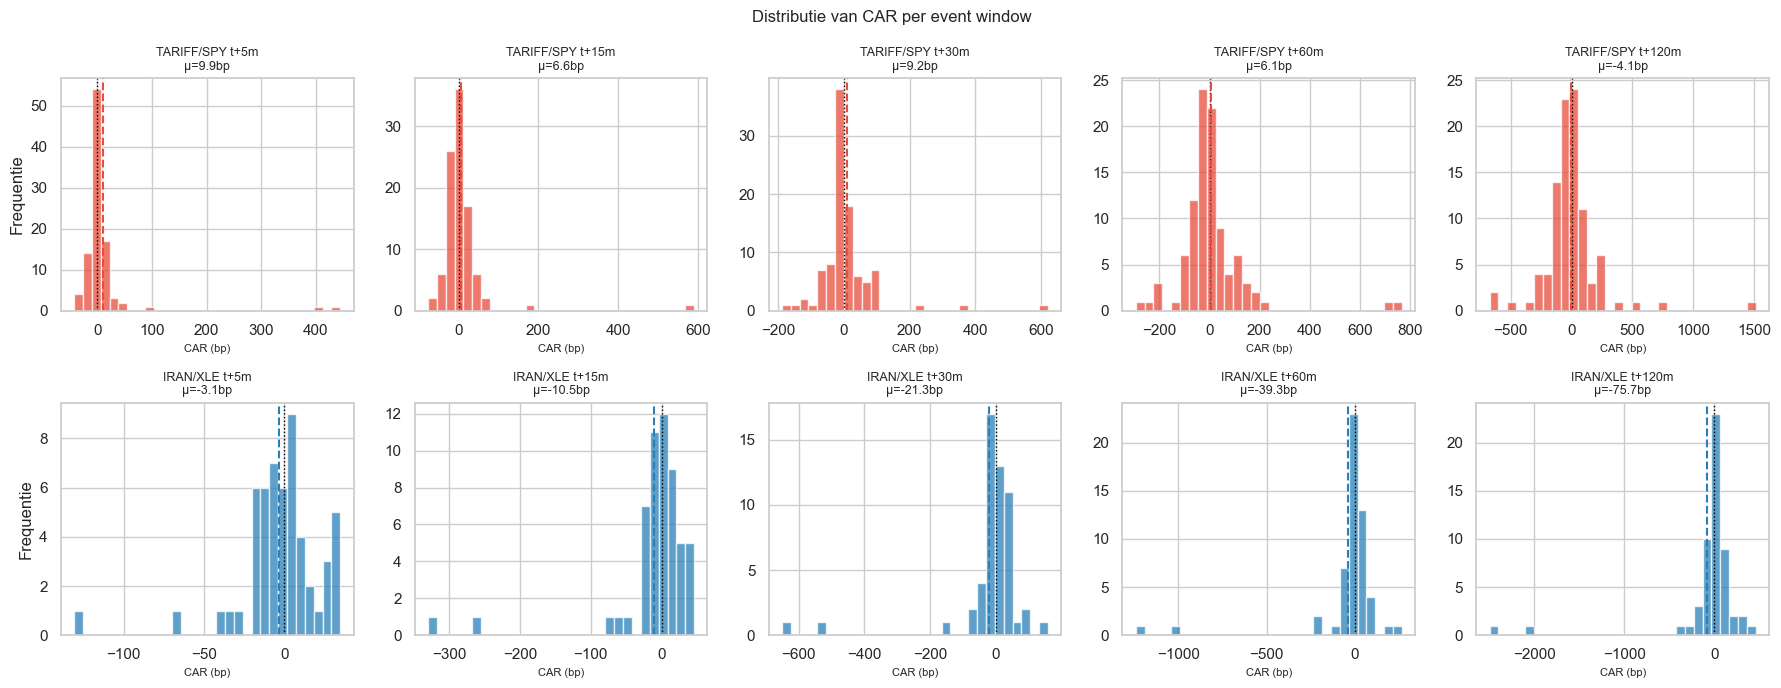

In [8]:
fig, axes = plt.subplots(2, len(WINDOWS), figsize=(18, 7), sharey=False)

for row_idx, (topic, ticker, df) in enumerate([
    ('tariff', 'SPY', tariff_spy_cars),
    ('iran',   'XLE', iran_xle_cars),
]):
    sub = df[df['in_market_hours']]
    color = '#e74c3c' if topic == 'tariff' else '#2980b9'
    for col_idx, w in enumerate(WINDOWS):
        col  = f'car_{w}m'
        vals = sub[col].dropna() * 1e4
        ax   = axes[row_idx][col_idx]
        ax.hist(vals, bins=30, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0,           color='black', linestyle=':', linewidth=1)
        ax.axvline(vals.mean(), color=color,   linestyle='--', linewidth=1.5)
        ax.set_title(f'{topic.upper()}/{ticker} t+{w}m\nμ={vals.mean():.1f}bp', fontsize=9)
        ax.set_xlabel('CAR (bp)', fontsize=8)
        if col_idx == 0:
            ax.set_ylabel('Frequentie')

plt.suptitle('Distributie van CAR per event window', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '12_intraday_car_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Volume-anomalie na posts

Stijgt het handelsvolume direct na een post? Dat is een proxy voor marktaandacht,
ook als de prijs niet beweegt.

Volume ratios berekenen...
Tariff posts - SPY: mean ratio=1.504  95%CI=[1.222, 1.848] (CI sluit 1 uit)
Iran posts - SPY: mean ratio=0.923  95%CI=[0.811, 1.052] (CI omvat 1)


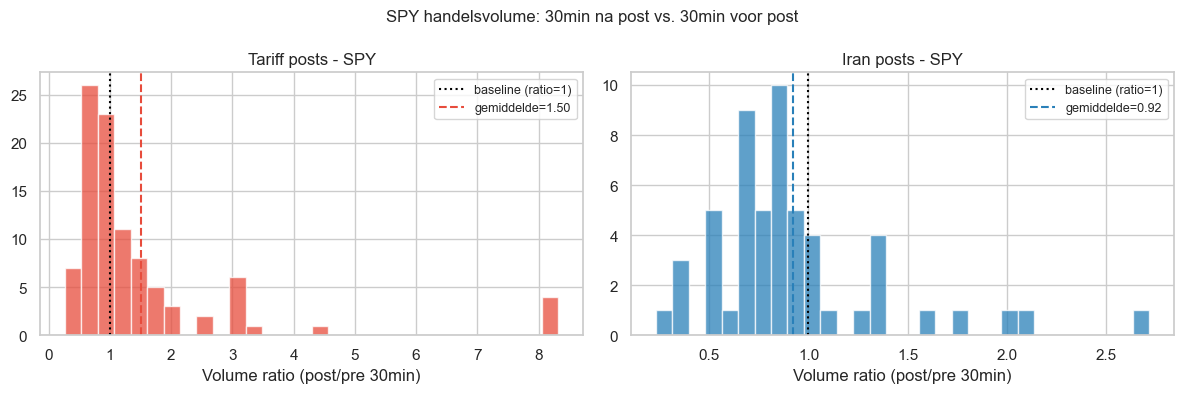

In [9]:
from src.evaluation.bootstrap import bootstrap_ci

def compute_volume_ratio(post_time: pd.Timestamp, market_df: pd.DataFrame,
                         window_m: int = 30, baseline_m: int = 30) -> float:
    """Volume in post-window gedeeld door volume in pre-window (ratio > 1 = meer volume)."""
    pre = market_df[
        (market_df['datetime'] > post_time - pd.Timedelta(minutes=baseline_m)) &
        (market_df['datetime'] <= post_time)
    ]['volume'].dropna()
    post = market_df[
        (market_df['datetime'] > post_time) &
        (market_df['datetime'] <= post_time + pd.Timedelta(minutes=window_m))
    ]['volume'].dropna()
    if pre.empty or post.empty or pre.mean() == 0:
        return np.nan
    return float(post.mean() / pre.mean())

print('Volume ratios berekenen...')
tariff_vol = pd.Series([
    compute_volume_ratio(t, spy_tariff) for t in tariff_ts
], name='vol_ratio')
iran_vol = pd.Series([
    compute_volume_ratio(t, spy_iran) for t in iran_ts
], name='vol_ratio')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, label, color in [
    (axes[0], tariff_vol.dropna(), 'Tariff posts - SPY', '#e74c3c'),
    (axes[1], iran_vol.dropna(),   'Iran posts - SPY',   '#2980b9'),
]:
    ax.hist(vals, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(1.0,         color='black', linestyle=':', linewidth=1.5, label='baseline (ratio=1)')
    ax.axvline(vals.mean(), color=color,   linestyle='--', linewidth=1.5, label=f'gemiddelde={vals.mean():.2f}')
    ax.set_title(label)
    ax.set_xlabel('Volume ratio (post/pre 30min)')
    ax.legend(fontsize=9)

    b = bootstrap_ci(vals, stat=np.mean, h0=1.0)   # toets tegen ratio = 1
    flag = 'CI sluit 1 uit' if b['excludes_h0'] else 'CI omvat 1'
    print(f'{label}: mean ratio={b["obs"]:.3f}  95%CI=[{b["ci_low"]:.3f}, {b["ci_high"]:.3f}] ({flag})')

plt.suptitle('SPY handelsvolume: 30min na post vs. 30min voor post', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '12_intraday_volume_ratio.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Tariff posts: escalatie vs. de-escalatie

Splits tariff-posts in twee groepen op basis van toon:
- **Escalatie**: tariff, retaliat, china, sanctions, ...
- **De-escalatie**: deal, pause, truce, negotiat, exemption, ...

Heeft de richting van de post invloed op de richting van de CAR?

Escalatie-posts: 122
De-escalatie-posts: 81

CAR t+30m (bootstrap-95%-CI op het verschil):
  Escalatie (n=35):    mean=-3.6bp
  De-escalatie (n=28): mean=2.3bp
  Verschil=-5.9bp  95%CI=[-42.2, 25.0]  (0 uitgesloten=False)


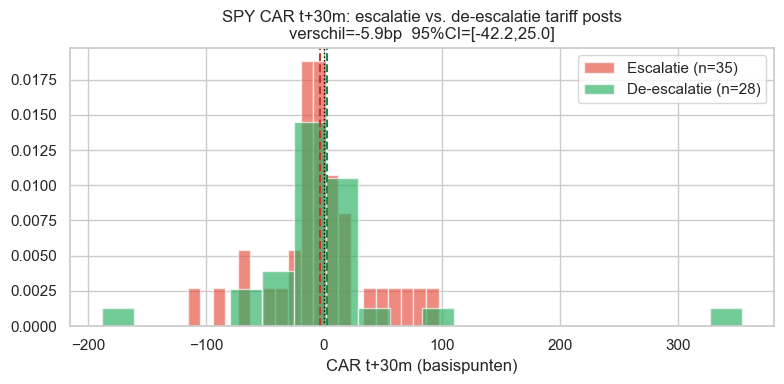

In [10]:
from src.evaluation.bootstrap import bootstrap_diff_ci

# pyarrow-first + text->string (zelfde robustheid als load_posts in cel 5)
try:
    df_posts = pd.read_parquet('../data/raw/posts.parquet', engine='pyarrow')
except Exception:
    df_posts = pd.read_parquet('../data/raw/posts.parquet', engine='fastparquet')
df_posts['timestamp_utc'] = pd.to_datetime(df_posts['timestamp_utc'], utc=True)
df_posts['text'] = df_posts['text'].astype('string').fillna('')

# Match tariff posts op tekst
tariff_df = df_posts[
    df_posts['text'].str.lower().str.contains('|'.join(TARIFF_KW), na=False, regex=True)
].copy()
tariff_df = tariff_df[
    (tariff_df['timestamp_utc'] >= pd.Timestamp('2025-02-01', tz='UTC')) &
    (tariff_df['timestamp_utc'] <= pd.Timestamp('2025-07-01', tz='UTC'))
].reset_index(drop=True)

ESCALATIE_KW = ['tariff', 'tariffs', 'retaliat', 'sanction', 'china will', 'will impose',
                '100%', '125%', '145%', 'reciprocal', 'tough']
DEESCALATIE_KW = ['deal', 'pause', 'truce', 'negotiat', 'exemption', 'agreement',
                  'great call', 'progress', 'reduce', 'cut tariff', 'lower']

esc_mask  = tariff_df['text'].str.lower().str.contains('|'.join(ESCALATIE_KW), na=False, regex=True)
dees_mask = tariff_df['text'].str.lower().str.contains('|'.join(DEESCALATIE_KW), na=False, regex=True)

esc_ts  = tariff_df[esc_mask & ~dees_mask]['timestamp_utc']
dees_ts = tariff_df[dees_mask & ~esc_mask]['timestamp_utc']

print(f'Escalatie-posts: {len(esc_ts)}')
print(f'De-escalatie-posts: {len(dees_ts)}')

# build_cars (cel 8) garandeert kolomschema, ook bij lege lijst
esc_cars  = build_cars(esc_ts,  spy_tariff)
dees_cars = build_cars(dees_ts, spy_tariff)

# Vergelijk CAR t+30m (waarden in basispunten)
esc_30  = esc_cars[esc_cars['in_market_hours'] == True]['car_30m'].dropna() * 1e4
dees_30 = dees_cars[dees_cars['in_market_hours'] == True]['car_30m'].dropna() * 1e4

if len(esc_30) >= 3 and len(dees_30) >= 3:
    b = bootstrap_diff_ci(esc_30, dees_30, stat=np.mean)   # verschil al in bp
    print(f'\nCAR t+30m (bootstrap-95%-CI op het verschil):')
    print(f'  Escalatie (n={len(esc_30)}):    mean={esc_30.mean():.1f}bp')
    print(f'  De-escalatie (n={len(dees_30)}): mean={dees_30.mean():.1f}bp')
    print(f'  Verschil={b["obs_diff"]:.1f}bp  95%CI=[{b["ci_low"]:.1f}, {b["ci_high"]:.1f}]  (0 uitgesloten={b["excludes_zero"]})')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(esc_30,  bins=20, alpha=0.65, color='#e74c3c', label=f'Escalatie (n={len(esc_30)})',    density=True)
    ax.hist(dees_30, bins=20, alpha=0.65, color='#27ae60', label=f'De-escalatie (n={len(dees_30)})', density=True)
    ax.axvline(esc_30.mean(),  color='#c0392b', linestyle='--', linewidth=1.5)
    ax.axvline(dees_30.mean(), color='#1e8449', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('CAR t+30m (basispunten)')
    ax.set_title(f'SPY CAR t+30m: escalatie vs. de-escalatie tariff posts\n'
                 f'verschil={b["obs_diff"]:.1f}bp  95%CI=[{b["ci_low"]:.1f},{b["ci_high"]:.1f}]')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / '12_escalatie_vs_deescalatie.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Te weinig posts voor vergelijking - pas keyword-lijsten aan.')


## 9. Mean reversion check

Keert de initiële CAR terug naar nul binnen het event window?
- **Geen reversion**: effect houdt aan → markt prijst nieuwe informatie permanent in
- **Snelle reversion**: markt overreageert en corrigeert → mogelijk ruis/noise trading

Top-impact posts (|CAR t+30m| > 60.6bp): 25


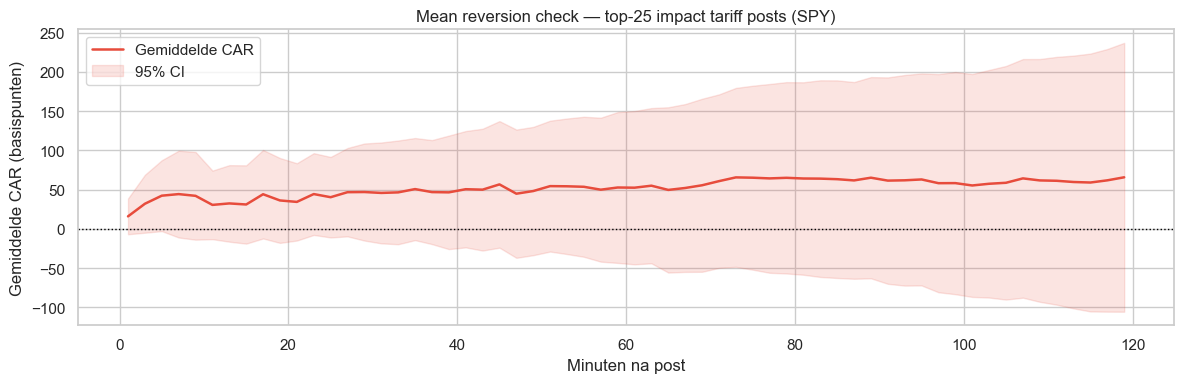

In [11]:
# Bereken CAR op elk minuut 1 t/m 120 voor de top-impact posts
# Top-impact = posts met |CAR t+30m| > 75e percentiel

FINE_WINDOWS = list(range(1, 121, 2))  # elke 2 minuten t/m 120

def compute_car_fine(post_time, market_df, fine_windows=FINE_WINDOWS):
    est_start = post_time - pd.Timedelta(minutes=30)
    est_data  = market_df[
        (market_df['datetime'] > est_start) &
        (market_df['datetime'] <= post_time)
    ]['return'].dropna()
    if len(est_data) < 5:
        return None
    baseline = est_data.mean()
    cars = []
    for w in fine_windows:
        ev = market_df[
            (market_df['datetime'] > post_time) &
            (market_df['datetime'] <= post_time + pd.Timedelta(minutes=w))
        ]['return'].dropna()
        cars.append((ev - baseline).sum() * 1e4 if not ev.empty else np.nan)
    return cars

# Selecteer top-impact tariff posts (grootste absolute CAR t+30m, tijdens markturen)
valid_tariff = tariff_spy_cars[tariff_spy_cars['in_market_hours'] & tariff_spy_cars['car_30m'].notna()].copy()
threshold    = valid_tariff['car_30m'].abs().quantile(0.75)
top_posts    = valid_tariff[valid_tariff['car_30m'].abs() >= threshold]
print(f'Top-impact posts (|CAR t+30m| > {threshold*1e4:.1f}bp): {len(top_posts)}')

fine_series = []
for _, row in top_posts.iterrows():
    cars = compute_car_fine(row['post_time'], spy_tariff)
    if cars:
        fine_series.append(cars)

if fine_series:
    fine_matrix = np.array(fine_series)
    mean_car    = np.nanmean(fine_matrix, axis=0)
    sem_car     = np.nanstd(fine_matrix, axis=0) / np.sqrt(np.sum(~np.isnan(fine_matrix), axis=0))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(FINE_WINDOWS, mean_car, color='#e74c3c', linewidth=1.8, label='Gemiddelde CAR')
    ax.fill_between(FINE_WINDOWS,
                    mean_car - 1.96 * sem_car,
                    mean_car + 1.96 * sem_car,
                    alpha=0.15, color='#e74c3c', label='95% CI')
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('Minuten na post')
    ax.set_ylabel('Gemiddelde CAR (basispunten)')
    ax.set_title(f'Mean reversion check — top-{len(top_posts)} impact tariff posts (SPY)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / '12_mean_reversion.png', dpi=150, bbox_inches='tight')
    plt.show()